<a href="https://colab.research.google.com/github/gmauricio-toledo/math-ML/blob/main/Notebooks/15-Regresion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Inicio

In [70]:
import pandas as pd

path = '/content/sample_data/california_housing_train.csv'

housing_df = pd.read_csv(path)
housing_df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0
...,...,...,...,...,...,...,...,...,...
16995,-124.26,40.58,52.0,2217.0,394.0,907.0,369.0,2.3571,111400.0
16996,-124.27,40.69,36.0,2349.0,528.0,1194.0,465.0,2.5179,79000.0
16997,-124.30,41.84,17.0,2677.0,531.0,1244.0,456.0,3.0313,103600.0
16998,-124.30,41.80,19.0,2672.0,552.0,1298.0,478.0,1.9797,85800.0


In [71]:
from sklearn.model_selection import train_test_split

X = housing_df.drop(columns='median_house_value').values
y = housing_df['median_house_value'].values

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    random_state=849,
                                                    train_size = 0.75
                                                    )

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((12750, 8), (4250, 8), (12750,), (4250,))

# Primer modelo de regresión lineal

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# model = LinearRegression()
model = DecisionTreeRegressor(max_depth=13)
# model = SVR()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error

train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"MAE entrenamiento: {train_mae:.2f}")
print(f"MAE prueba: {test_mae:.2f}")

MAE entrenamiento: 19883.39
MAE prueba: 41589.79


In [ ]:
coefs = model.coef_

In [ ]:
cols = housing_df.drop(columns='median_house_value').columns

for c,coef in zip(cols,coefs):
  print(f"{c}: {coef:.2f}")

longitude: -441233.22
latitude: -412788.42
housing_median_age: 58244.97
total_rooms: -272198.82
total_bedrooms: 709208.74
population: -1319237.07
households: 304552.45
median_income: 583022.84


In [ ]:
model.score(X_train, y_train)

0.6385264164764849

# Pipeline

Regresión cuadrática

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pf = PolynomialFeatures(degree=2)
X_train_pf = pf.fit_transform(X_train_scaled)
X_test_pf = pf.transform(X_test_scaled)

model = LinearRegression()
model.fit(X_train_pf, y_train)

y_train_pred = model.predict(X_train_pf)
y_test_pred = model.predict(X_test_pf)

print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")

Train MAE: 44700.24
Test MAE: 44633.23


In [ ]:
from sklearn.pipeline import Pipeline

pipeline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=2)),
    ('model', LinearRegression())
])

pipeline_model.fit(X_train, y_train)

y_train_pred = pipeline_model.predict(X_train)
y_test_pred = pipeline_model.predict(X_test)

print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")

Train MAE: 44700.24
Test MAE: 44633.23


# Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import PolynomialFeatures

pipeline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(degree=1)),
    ('model', LinearRegression())
])

scores = cross_val_score(pipeline_model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
print(f"Scores: {scores}")
print(f"Promedio de errores: {-scores.mean():.2f}")

Scores: [-51236.38790675 -52316.98680488 -50841.28385596 -49906.30490032
 -50956.80585298]
Promedio de errores: 51051.55


# GridSearch

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error

X_train_scl = scaler.fit_transform(X_train)
X_test_scl = scaler.transform(X_test)

model = KNeighborsRegressor()

param_grid = {
    'n_neighbors': [3, 5, 7, 9],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_absolute_error')
grid_search.fit(X_train_scl, y_train)

GridSearchCV(cv=5, estimator=KNeighborsRegressor(),
             param_grid={'n_neighbors': [3, 5, 7, 9], 'p': [1, 2],
                         'weights': ['uniform', 'distance']},
             scoring='neg_mean_absolute_error')

Veamos los mejores parámetros

In [ ]:
grid_search.best_params_

{'n_neighbors': 9, 'p': 1, 'weights': 'distance'}

Escogemos el mejor modelo

In [ ]:
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train_scl)
y_test_pred = best_model.predict(X_test_scl)

print(f"Train MAE: {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_test_pred):.2f}")

Train MAE: 0.00
Test MAE: 40364.04


Un grid search más completo. Tarda alrededor de 8 minutos

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, f_regression

# Crear el pipeline inicial
pipeline_model = Pipeline([
    ('scaler', StandardScaler()),
    ('selector', SelectKBest(score_func=f_regression, k=5)),
    ('model', LinearRegression())
])

# Definir una lista de diccionarios para que cada modelo busque solo sus parámetros válidos
param_grid = [
    {
        'model': [LinearRegression()],
        'selector__k': [4, 6, 8],
        'scaler': [StandardScaler(), MinMaxScaler()]
    },
    {
        'model': [DecisionTreeRegressor()],
        'model__max_depth': [4, 6, 8, 10, 12],
        'selector__k': [4, 6, 8],
        'scaler': [StandardScaler(), MinMaxScaler()]
    },
    {
        'model': [SVR()],
        'model__kernel': ['linear', 'rbf', 'poly'],
        'selector__k': [4, 6, 8],
        'scaler': [StandardScaler(), MinMaxScaler()]
    }
]

# Inicializamos la clase que hará la búsqueda de parámetros
grid_search = GridSearchCV(pipeline_model, param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
# Entrenamos (realizamos la búsqueda de parámetros)
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('selector',
                                        SelectKBest(k=5,
                                                    score_func=<function f_regression at 0x7cfedd3e93a0>)),
                                       ('model', LinearRegression())]),
             n_jobs=-1,
             param_grid=[{'model': [LinearRegression()],
                          'scaler': [StandardScaler(), MinMaxScaler()],
                          'selector__k': [4, 6, 8]},
                         {'model': [DecisionTreeRegressor()],
                          'model__max_depth': [4, 6, 8, 10, 12],
                          'scaler': [StandardScaler(), MinMaxScaler()],
                          'selector__k': [4, 6, 8]},
                         {'model': [SVR()],
                          'model__kernel': ['linear', 'rbf', 'poly'],
                          'scaler': [StandardScaler(), MinMaxScaler()],
                          'selector__k': [4, 6, 8]}],
             scoring='neg_mean_absolute_error')

Mejores parámetros

In [74]:
grid_search.best_params_

{'model': DecisionTreeRegressor(),
 'model__max_depth': 12,
 'scaler': StandardScaler(),
 'selector__k': 8}

Evaluamos con el mejor modelo

In [75]:
# Escogemos el mejor modelo
best_model = grid_search.best_estimator_ # best_model es un modelo de regresión ya entrenado

# Hacemos las predicciones
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# Evaluamos las predicciones
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"MAE entrenamiento: {train_mae:.2f}")
print(f"MAE prueba: {test_mae:.2f}")

MAE entrenamiento: 23724.69
MAE prueba: 41704.04


# Varios Modelos

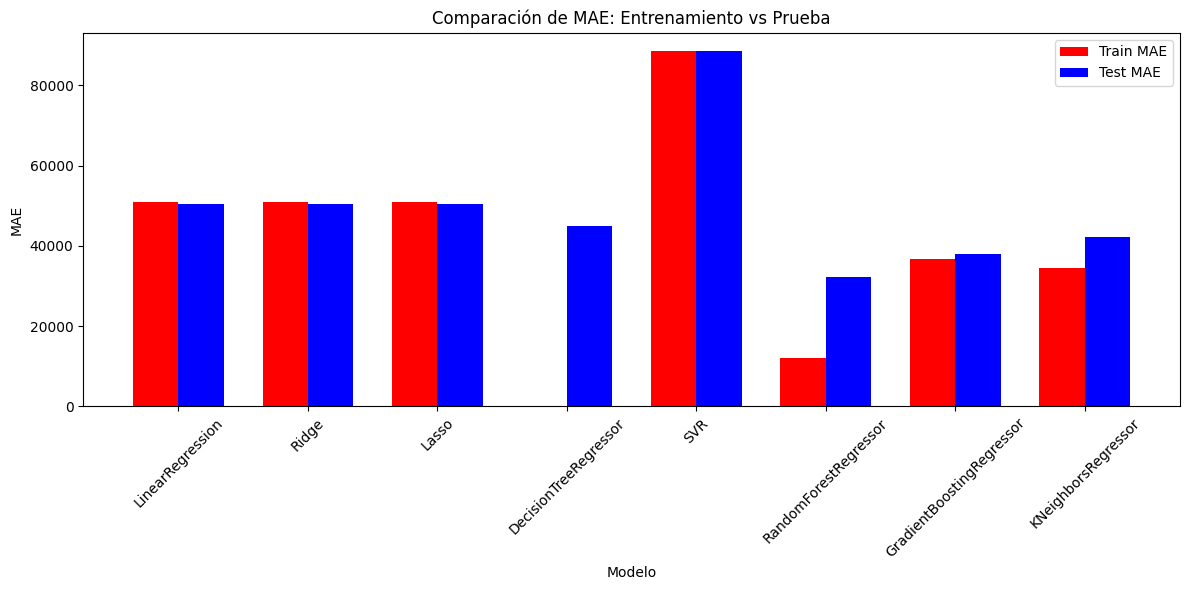

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

regresores = [
    LinearRegression(),
    Ridge(),
    Lasso(),
    DecisionTreeRegressor(),
    SVR(),
    RandomForestRegressor(),
    GradientBoostingRegressor(),
    KNeighborsRegressor()
]

names = [r.__class__.__name__ for r in regresores]
train_maes = []
test_maes = []

for regresor, name in zip(regresores, names):
    pipeline_model = Pipeline([
        ('scaler', StandardScaler()),
        (name, regresor)
    ])

    pipeline_model.fit(X_train, y_train)
    y_train_pred = pipeline_model.predict(X_train)
    y_test_pred = pipeline_model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    train_maes.append(train_mae)
    test_maes.append(test_mae)

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, train_maes, width, label='Train MAE', color='red')
plt.bar(x + width/2, test_maes, width, label='Test MAE', color='blue')

plt.xlabel('Modelo')
plt.ylabel('MAE')
plt.title('Comparación de MAE: Entrenamiento vs Prueba')
plt.xticks(x, names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 🔴 Trabajo en clase

Encuentra el menor error MAE que puedas conseguir usando regresión polinomial, grid search y un pipeline.

1. Separa el conjunto de prueba en train-test con la misma proporción y seed usado en clase
2. Define un pipeline que conste de: reescalamiento, polynomial features, regresión lineal
3. Define un grid de parametros donde pruebes al menos 3 grados polinomiales, además del grado 1. Prueba también entre `MinMaxScaler` y `StandardScaler`como métodos de re-escalamiento.
4. Haz la busqueda de parámetros
5. Imprime los mejores parámetros
6. Toma el mejor modelo de la busqueda y realiza las predicciones en el conjunto de prueba, evalua el error MAE.
7. Comparalo con el primer modelo evaluado en clase